In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned Australian Government bond yields
yields = pd.read_csv(
    "../data/processed/au_government_yields.csv",
    parse_dates=["Date"]
)

yields.head()

,Date,2Y,3Y,5Y,10Y,2s10s_bp,3s10s_bp,2s5s_bp
0,2013-05-20,NaN,NaN,NaN,3.229,NaN,NaN,NaN
1,2013-05-21,NaN,NaN,NaN,3.263,NaN,NaN,NaN
2,2013-05-22,NaN,NaN,NaN,3.272,NaN,NaN,NaN
3,2013-05-23,NaN,NaN,NaN,3.299,NaN,NaN,NaN
4,2013-05-24,NaN,NaN,NaN,3.316,NaN,NaN,NaN


In [3]:
rba_events = pd.DataFrame({
    "Meeting Date": pd.to_datetime([
        "2025-02-18",
        "2025-04-01",
        "2025-05-20",
        "2025-07-08",
        "2025-08-12",
        "2025-09-30",
        "2025-11-04",
        "2025-12-09",
        "2026-02-03",
        "2026-03-17",
        "2026-05-05",
        "2026-06-16",
        "2026-08-11"
    ]),
    "Decision (bp)": [
        -25,
        0,
        -25,
        0,
        -25,
        0,
        0,
        0,
        25,
        25,
        25,
        0,
        0
    ],
    "Cash Rate (%)": [
        4.10,
        4.10,
        3.85,
        3.85,
        3.60,
        3.60,
        3.60,
        3.60,
        3.85,
        4.10,
        4.35,
        4.35,
        4.35
    ]
})

rba_events


,Meeting Date,Decision (bp),Cash Rate (%)
0,2025-02-18,-25,4.10
1,2025-04-01,0,4.10
2,2025-05-20,-25,3.85
3,2025-07-08,0,3.85
4,2025-08-12,-25,3.60
5,2025-09-30,0,3.60
6,2025-11-04,0,3.60
7,2025-12-09,0,3.60
8,2026-02-03,25,3.85
9,2026-03-17,25,4.10


In [4]:
def classify_decision(bp):
    if bp > 0:
        return "Hike"
    elif bp < 0:
        return "Cut"
    else:
        return "Hold"

rba_events["Decision Type"] = rba_events["Decision (bp)"].apply(classify_decision)

rba_events

,Meeting Date,Decision (bp),Cash Rate (%),Decision Type
0,2025-02-18,-25,4.10,Cut
1,2025-04-01,0,4.10,Hold
2,2025-05-20,-25,3.85,Cut
3,2025-07-08,0,3.85,Hold
4,2025-08-12,-25,3.60,Cut
5,2025-09-30,0,3.60,Hold
6,2025-11-04,0,3.60,Hold
7,2025-12-09,0,3.60,Hold
8,2026-02-03,25,3.85,Hike
9,2026-03-17,25,4.10,Hike


In [5]:
def get_yield_before(date):
    available = yields[yields["Date"] < date]

    if available.empty:
        return None

    return available.iloc[-1]


def get_yield_on_or_after(date):
    available = yields[yields["Date"] >= date]

    if available.empty:
        return None

    return available.iloc[0]

In [6]:
event_results = []

for _, event in rba_events.iterrows():

    meeting_date = event["Meeting Date"]

    before = get_yield_before(meeting_date)
    after = get_yield_on_or_after(meeting_date)

    if before is None or after is None:
        continue

    result = {
        "Meeting Date": meeting_date,
        "Decision Type": event["Decision Type"],
        "Decision (bp)": event["Decision (bp)"],
        "Cash Rate (%)": event["Cash Rate (%)"],

        "Before Date": before["Date"],
        "After Date": after["Date"],

        "2Y Change (bp)": (after["2Y"] - before["2Y"]) * 100,
        "3Y Change (bp)": (after["3Y"] - before["3Y"]) * 100,
        "5Y Change (bp)": (after["5Y"] - before["5Y"]) * 100,
        "10Y Change (bp)": (after["10Y"] - before["10Y"]) * 100,

        "2s10s Change (bp)": (
            (after["10Y"] - after["2Y"])
            -
            (before["10Y"] - before["2Y"])
        ) * 100
    }

    event_results.append(result)

event_study = pd.DataFrame(event_results)

event_study = event_study.round(1)

event_study

/tmp/ipykernel_4046/2721481564.py:38: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  event_study = event_study.round(1)


,Meeting Date,Decision Type,Decision (bp),Cash Rate (%),Before Date,After Date,2Y Change (bp),3Y Change (bp),5Y Change (bp),10Y Change (bp),2s10s Change (bp)
0,2025-02-18,Cut,-25,4.1,2025-02-17,2025-02-18,5.4,5.5,5.6,5.4,0.0
1,2025-04-01,Hold,0,4.1,2025-03-31,2025-04-01,-0.9,-0.3,0.1,-1.1,-0.2
2,2025-05-20,Cut,-25,3.8,2025-05-19,2025-05-20,-16.4,-16.9,-15.5,-12.4,4.0
3,2025-07-08,Hold,0,3.8,2025-07-07,2025-07-08,11.6,11.1,10.6,8.1,-3.5
4,2025-08-12,Cut,-25,3.6,2025-08-11,2025-08-12,-1.1,-1.0,-1.2,-0.6,0.5
5,2025-09-30,Hold,0,3.6,2025-09-29,2025-09-30,1.2,0.9,-0.2,-3.5,-4.7
6,2025-11-04,Hold,0,3.6,2025-11-03,2025-11-04,2.5,3.4,3.0,1.5,-1.0
7,2025-12-09,Hold,0,3.6,2025-12-08,2025-12-09,9.7,10.2,9.0,5.4,-4.3
8,2026-02-03,Hike,25,3.8,2026-02-02,2026-02-03,7.4,6.5,5.6,3.7,-3.7
9,2026-03-17,Hike,25,4.1,2026-03-16,2026-03-17,-2.2,-4.2,-4.6,-6.2,-4.0


In [7]:
reaction_cols = [
    "2Y Change (bp)",
    "3Y Change (bp)",
    "5Y Change (bp)",
    "10Y Change (bp)",
    "2s10s Change (bp)"
]

decision_summary = (
    event_study
    .groupby("Decision Type")[reaction_cols]
    .mean()
    .round(1)
)

decision_summary

,2Y Change (bp),3Y Change (bp),5Y Change (bp),10Y Change (bp),2s10s Change (bp)
Decision Type,,,,,
Cut,-4.0,-4.1,-3.7,-2.5,1.5
Hike,1.0,-0.3,-0.6,-1.2,-2.2
Hold,3.7,3.9,3.7,2.3,-1.4


In [8]:
absolute_reaction = (
    event_study
    .groupby("Decision Type")[reaction_cols[:-1]]
    .apply(lambda x: x.abs().mean())
    .round(1)
)

absolute_reaction

,2Y Change (bp),3Y Change (bp),5Y Change (bp),10Y Change (bp)
Decision Type,,,,
Cut,7.6,7.8,7.4,6.1
Hike,3.9,4.6,4.3,3.6
Hold,4.1,4.1,3.8,3.7


In [9]:
tenor_sensitivity = (
    event_study[reaction_cols[:-1]]
    .abs()
    .mean()
    .sort_values(ascending=False)
    .round(1)
)

tenor_sensitivity

3Y Change (bp)     5.1
2Y Change (bp)     4.9
5Y Change (bp)     4.7
10Y Change (bp)    4.2
dtype: float64

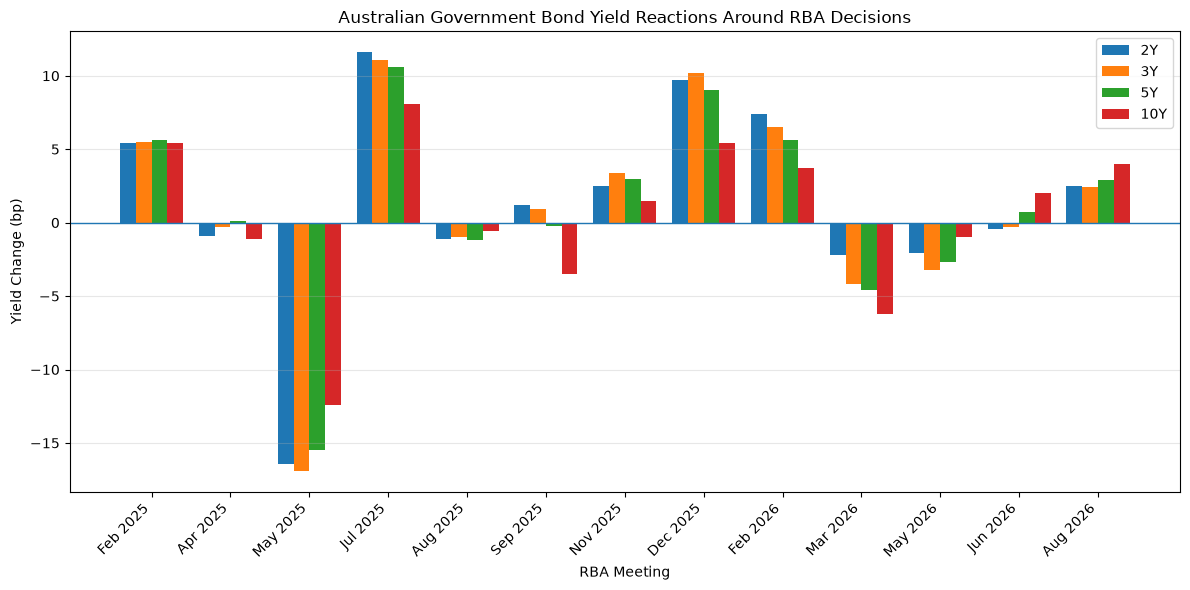

In [18]:
plt.figure(figsize=(12, 6))

x = np.arange(len(event_study))
width = 0.2

plt.bar(
    x - 1.5 * width,
    event_study["2Y Change (bp)"],
    width,
    label="2Y"
)

plt.bar(
    x - 0.5 * width,
    event_study["3Y Change (bp)"],
    width,
    label="3Y"
)

plt.bar(
    x + 0.5 * width,
    event_study["5Y Change (bp)"],
    width,
    label="5Y"
)

plt.bar(
    x + 1.5 * width,
    event_study["10Y Change (bp)"],
    width,
    label="10Y"
)

plt.axhline(0, linewidth=1)

plt.xticks(
    x,
    event_study["Meeting Date"].dt.strftime("%b %Y"),
    rotation=45,
    ha="right"
)

plt.ylabel("Yield Change (bp)")
plt.xlabel("RBA Meeting")
plt.title("Australian Government Bond Yield Reactions Around RBA Decisions")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/rba_yield_reactions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
curve_reaction = event_study[
    [
        "Meeting Date",
        "Decision Type",
        "Decision (bp)",
        "2s10s Change (bp)"
    ]
].copy()

curve_reaction

,Meeting Date,Decision Type,Decision (bp),2s10s Change (bp)
0,2025-02-18,Cut,-25,0.0
1,2025-04-01,Hold,0,-0.2
2,2025-05-20,Cut,-25,4.0
3,2025-07-08,Hold,0,-3.5
4,2025-08-12,Cut,-25,0.5
5,2025-09-30,Hold,0,-4.7
6,2025-11-04,Hold,0,-1.0
7,2025-12-09,Hold,0,-4.3
8,2026-02-03,Hike,25,-3.7
9,2026-03-17,Hike,25,-4.0


In [12]:
def classify_curve_move(change):
    if change > 0:
        return "Steepening"
    elif change < 0:
        return "Flattening"
    else:
        return "Unchanged"

curve_reaction["Curve Move"] = (
    curve_reaction["2s10s Change (bp)"]
    .apply(classify_curve_move)
)

curve_reaction

,Meeting Date,Decision Type,Decision (bp),2s10s Change (bp),Curve Move
0,2025-02-18,Cut,-25,0.0,Unchanged
1,2025-04-01,Hold,0,-0.2,Flattening
2,2025-05-20,Cut,-25,4.0,Steepening
3,2025-07-08,Hold,0,-3.5,Flattening
4,2025-08-12,Cut,-25,0.5,Steepening
5,2025-09-30,Hold,0,-4.7,Flattening
6,2025-11-04,Hold,0,-1.0,Flattening
7,2025-12-09,Hold,0,-4.3,Flattening
8,2026-02-03,Hike,25,-3.7,Flattening
9,2026-03-17,Hike,25,-4.0,Flattening


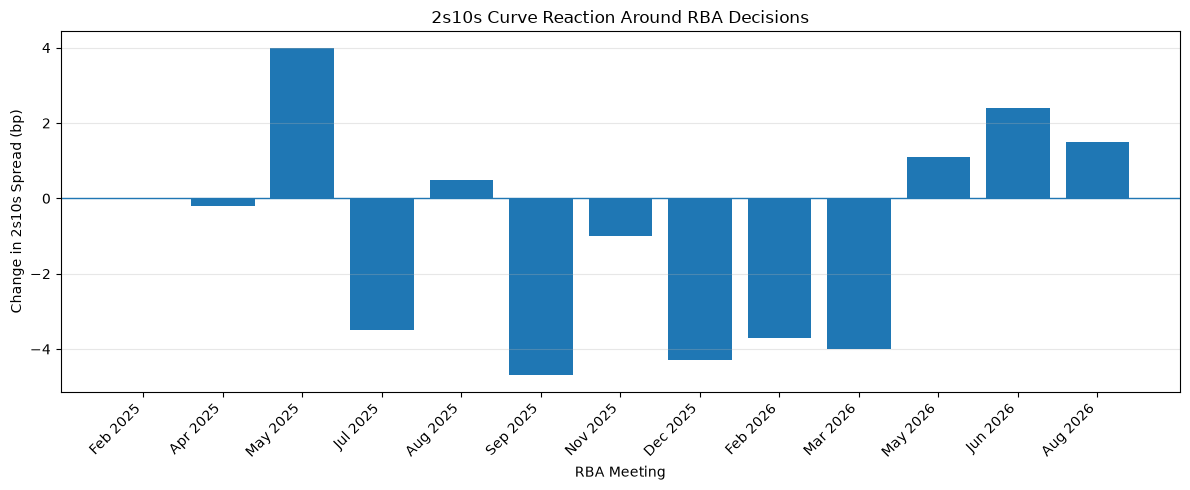

In [16]:
plt.figure(figsize=(12, 5))

plt.bar(
    event_study["Meeting Date"].dt.strftime("%b %Y"),
    event_study["2s10s Change (bp)"]
)

plt.axhline(0, linewidth=1)

plt.title("2s10s Curve Reaction Around RBA Decisions")
plt.xlabel("RBA Meeting")
plt.ylabel("Change in 2s10s Spread (bp)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/rba_2s10s_reactions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
reaction_cols = [
    "2Y Change (bp)",
    "3Y Change (bp)",
    "5Y Change (bp)",
    "10Y Change (bp)",
    "2s10s Change (bp)"
]

signed_summary = (
    event_study
    .groupby("Decision Type")[reaction_cols]
    .mean()
    .round(1)
)

signed_summary

,2Y Change (bp),3Y Change (bp),5Y Change (bp),10Y Change (bp),2s10s Change (bp)
Decision Type,,,,,
Cut,-4.0,-4.1,-3.7,-2.5,1.5
Hike,1.0,-0.3,-0.6,-1.2,-2.2
Hold,3.7,3.9,3.7,2.3,-1.4


In [15]:
sample_size = (
    event_study["Decision Type"]
    .value_counts()
    .rename("Number of Meetings")
)

sample_size

Decision Type
Hold    7
Cut     3
Hike    3
Name: Number of Meetings, dtype: int64

In [17]:
event_study.to_csv(
    "../outputs/tables/rba_event_study.csv",
    index=False
)

signed_summary.to_csv(
    "../outputs/tables/rba_signed_reaction_summary.csv"
)

curve_reaction.to_csv(
    "../outputs/tables/rba_curve_reactions.csv",
    index=False
)

print("Component 2 tables saved successfully.")

Component 2 tables saved successfully.


## Market Interpretation

The event study shows that Australian Government bond yields do not respond mechanically to the headline direction of an RBA decision.

Across the sample, rate cuts were associated with the largest average absolute yield reactions, particularly in the 2-year to 5-year sector. On a signed basis, cuts were associated with average declines of approximately 4 bp in the 2-year and 3-year yields, compared with around 2.5 bp in the 10-year yield. This resulted in modest average steepening of the 2s10s curve.

Hold decisions also coincided with meaningful market repricing. On average, yields increased by approximately 3.7–3.9 bp across the 2-year to 5-year sector and by around 2.3 bp at the 10-year maturity, resulting in modest flattening.

The reaction to hikes was less uniform. The 2-year yield increased slightly on average, while longer maturities declined modestly. Given the small number of hike observations, this should be interpreted cautiously.

A particularly important result is that identical headline decisions produced very different market reactions. For example, the February 2025 cut coincided with higher yields across the curve, while the May 2025 cut coincided with a substantial decline in yields.

This illustrates a central feature of rates markets: market prices respond not simply to whether the RBA hikes, cuts or holds, but to how the decision, accompanying communication and economic information compare with what investors had already expected.

### Limitations

This analysis uses end-of-day yield observations around RBA meeting dates. It therefore identifies market movements associated with the event window rather than proving that the RBA decision alone caused the change. Other domestic and global information may also affect yields during the same period. The number of cuts and hikes in the sample is small, so the results should be interpreted descriptively rather than as statistically robust causal estimates.